# 07 — Phân tích giả thuyết nguyên nhân ô nhiễm

Notebook xếp hạng **các điều kiện đóng góp có thể xảy ra**, không thực hiện source apportionment và không khẳng định nhân quả. Mỗi kết quả được so với baseline median/IQR của đúng trạm và tháng, kèm evidence JSON, độ mạnh bằng chứng và guardrail cho GenAI.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import JSON, Markdown, display

sns.set_theme(style='whitegrid', palette='colorblind')
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
report = json.loads((ROOT / 'artifacts' / 'pollution_cause_analysis_report.json').read_text(encoding='utf-8'))
columns = [
    'split', 'timestamp', 'station_id', 'location_name', 'pm25',
    'pm25_rolling_mean_24h', 'pm25_to_pm10_ratio', 'co', 'no2', 'so2', 'o3',
    'temperature', 'humidity', 'wind_speed', 'precipitation',
    'city_affected_fraction', 'top_hypothesis', 'top_hypothesis_vi',
    'top_hypothesis_score', 'second_hypothesis_vi', 'evidence_strength',
    'evidence_json', 'hypothesis_scores_json', 'genai_context_json',
    'causal_claim_allowed'
]
events = pd.read_csv(
    ROOT / 'data' / 'processed' / 'pollution_cause_analysis.csv.gz',
    usecols=columns, low_memory=False
)
events['timestamp'] = pd.to_datetime(events['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
display(pd.Series({
    'Số sự kiện': len(events),
    'Train': events['split'].eq('train').sum(),
    'Validation': events['split'].eq('validation').sum(),
    'Test': events['split'].eq('test').sum(),
    'Cho phép khẳng định nhân quả': events['causal_claim_allowed'].any(),
}).to_frame('Giá trị'))

,Giá trị
Số sự kiện,33887
Train,13485
Validation,14524
Test,5878
Cho phép khẳng định nhân quả,False


## 1. Dữ liệu có và chưa có

Baseline được fit trên train 2022–2024 theo `station_id × month`. Traffic lịch sử, thành phần hóa học, kiểm kê phát thải và back-trajectory hiện chưa có nên không được dùng làm bằng chứng.

In [2]:
availability = pd.Series(report['data_availability'], name='Có dữ liệu').to_frame()
display(availability)
display(pd.DataFrame({
    'Giới hạn': report['limitations']
}))

,Có dữ liệu
historical_traffic,False
chemical_speciation,False
emission_inventory,False
back_trajectory,False
pollutants_and_weather,True


,Giới hạn
0,"Các điểm Hà Nội dùng ước lượng CAMS, không phả..."
1,"Không có dữ liệu thành phần ion, carbon hay ki..."
2,Không có kiểm kê phát thải hoặc quỹ đạo khối k...
3,"TomTom chỉ có snapshot hiện tại, không đủ để q..."
4,"Điểm giả thuyết biểu thị độ mạnh bằng chứng, k..."


## 2. Phân bố giả thuyết đứng đầu

,top_hypothesis,top_hypothesis_vi,events,percent
0,regional_accumulation,Tích tụ trên diện rộng,13612,40.17
1,combustion_traffic_proxy,Tín hiệu đốt cháy/giao thông,8651,25.53
2,photochemical_conditions,Điều kiện quang hóa,6430,18.97
3,secondary_aerosol_conditions,Điều kiện hình thành aerosol thứ cấp,2175,6.42
4,unresolved,Chưa đủ bằng chứng,1714,5.06
5,atmospheric_stagnation,Khí quyển ít khuếch tán,1003,2.96
6,coarse_dust_resuspension,Bụi thô hoặc tái huyền phù,302,0.89


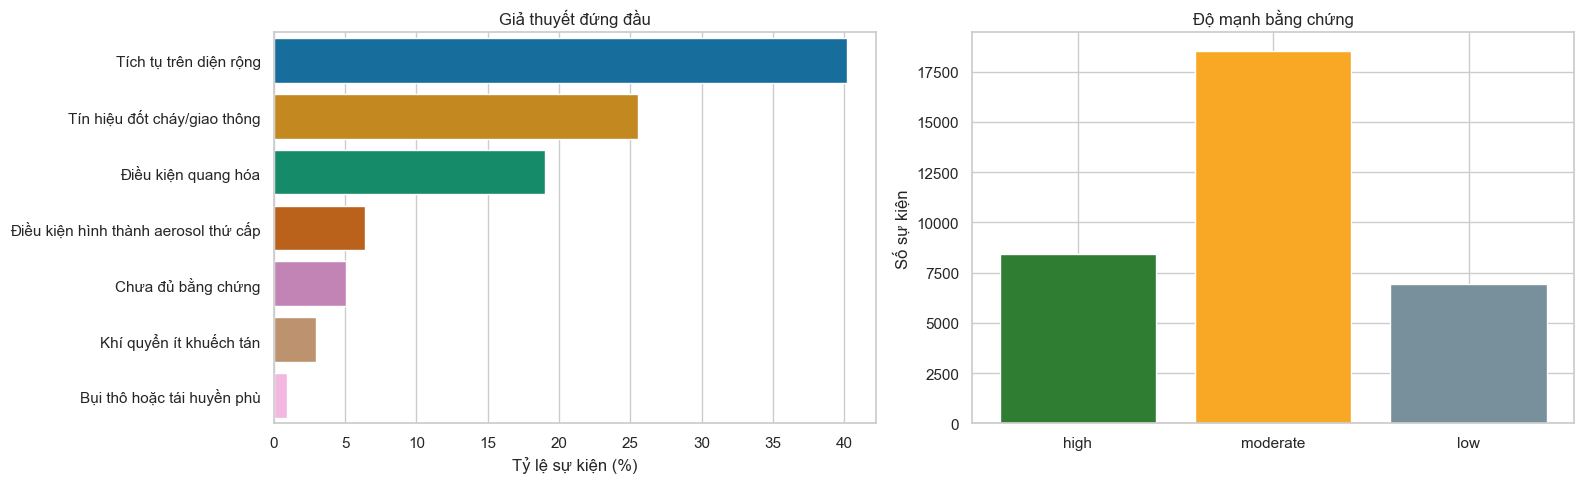

In [3]:
distribution = pd.DataFrame(report['hypothesis_distribution'])
display(distribution.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=distribution, y='top_hypothesis_vi', x='percent', ax=axes[0])
axes[0].set(title='Giả thuyết đứng đầu', xlabel='Tỷ lệ sự kiện (%)', ylabel='')
confidence_order = ['high', 'moderate', 'low']
confidence = events['evidence_strength'].value_counts().reindex(confidence_order).fillna(0)
axes[1].bar(confidence.index, confidence.values, color=['#2e7d32', '#f9a825', '#78909c'])
axes[1].set(title='Độ mạnh bằng chứng', xlabel='', ylabel='Số sự kiện')
plt.tight_layout()
plt.show()

## 3. Giả thuyết thay đổi theo split và thời gian

top_hypothesis_vi,Bụi thô hoặc tái huyền phù,Chưa đủ bằng chứng,Khí quyển ít khuếch tán,Tích tụ trên diện rộng,Tín hiệu đốt cháy/giao thông,Điều kiện hình thành aerosol thứ cấp,Điều kiện quang hóa
split,,,,,,,
test,0.02,3.33,3.64,39.45,22.69,8.30,22.56
train,1.97,8.83,4.12,41.39,22.87,1.52,19.30
validation,0.24,2.25,1.61,39.32,29.14,10.20,17.23


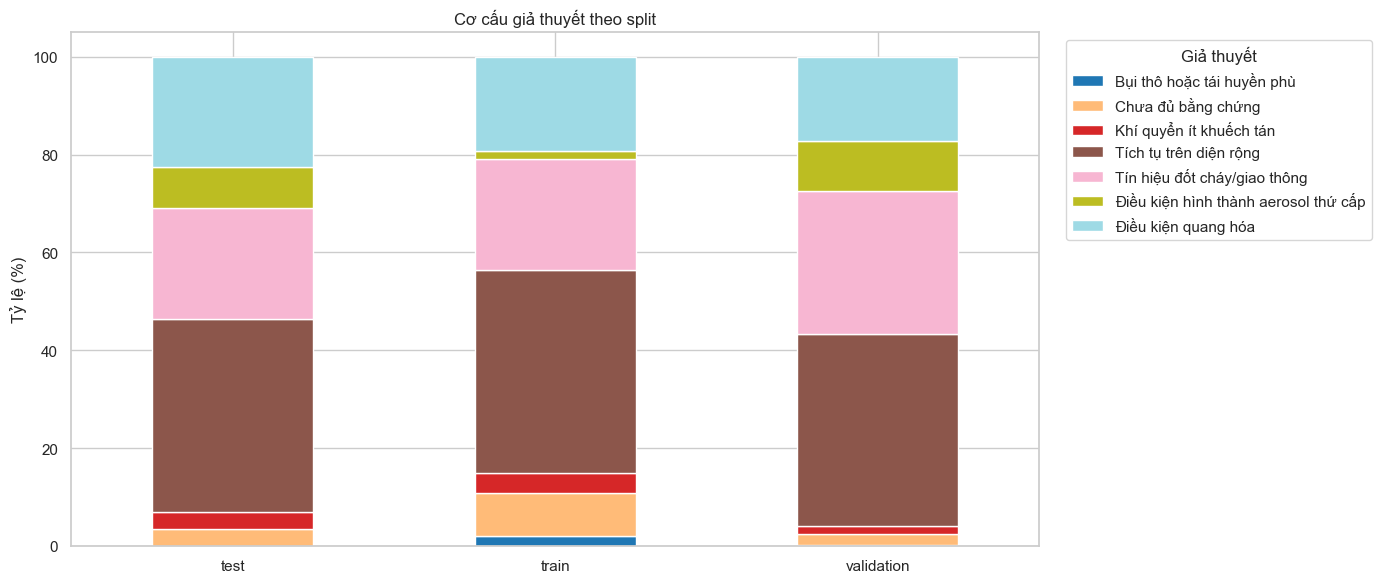

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_9836\881075643.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  events['timestamp'].dt.to_period('M').astype(str),


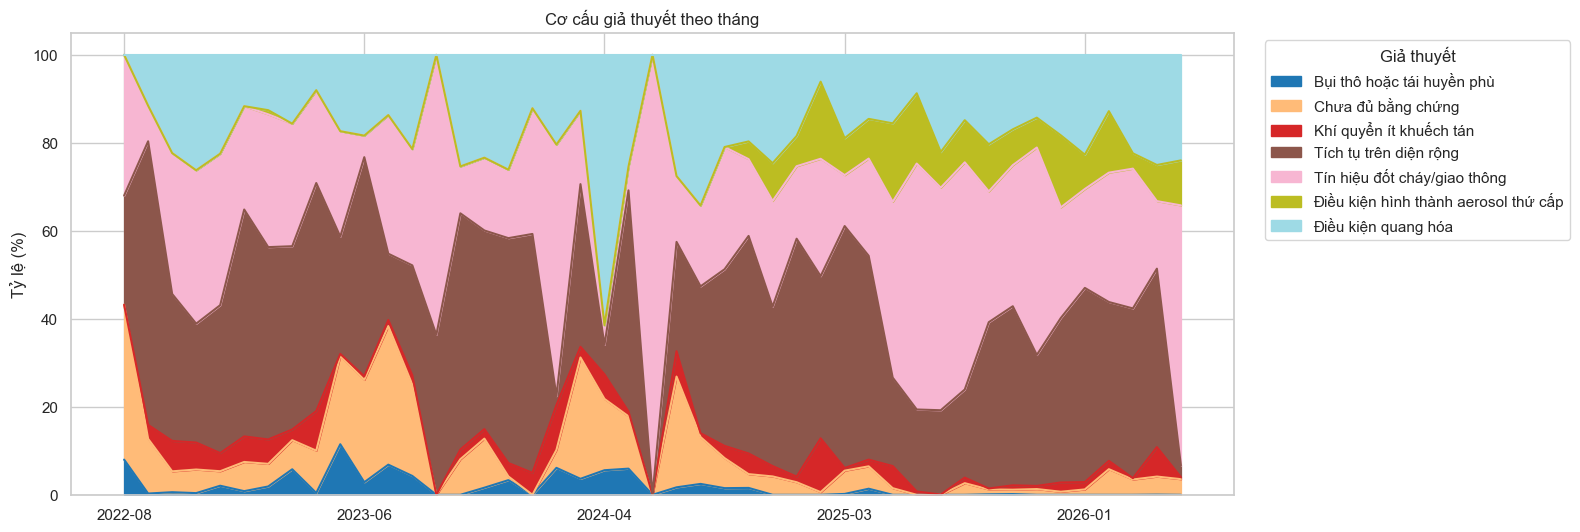

In [4]:
split_mix = pd.crosstab(events['split'], events['top_hypothesis_vi'], normalize='index').mul(100)
display(split_mix.round(2))
split_mix.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title('Cơ cấu giả thuyết theo split')
plt.xlabel('')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Giả thuyết', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

monthly = pd.crosstab(
    events['timestamp'].dt.to_period('M').astype(str),
    events['top_hypothesis_vi'], normalize='index'
).mul(100)
monthly.plot.area(figsize=(15, 6), colormap='tab20')
plt.title('Cơ cấu giả thuyết theo tháng')
plt.xlabel('')
plt.ylabel('Tỷ lệ (%)')
plt.legend(title='Giả thuyết', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

## 4. Tín hiệu trung bình đi kèm từng giả thuyết

Bảng này dùng để sanity-check logic; không được diễn giải thành phần trăm đóng góp nguồn.

In [5]:
signal_summary = events.groupby('top_hypothesis_vi').agg(
    events=('pm25', 'size'),
    pm25=('pm25', 'mean'),
    pm25_24h=('pm25_rolling_mean_24h', 'mean'),
    fine_ratio=('pm25_to_pm10_ratio', 'mean'),
    co=('co', 'mean'),
    no2=('no2', 'mean'),
    o3=('o3', 'mean'),
    temperature=('temperature', 'mean'),
    humidity=('humidity', 'mean'),
    wind_speed=('wind_speed', 'mean'),
    rain=('precipitation', 'mean'),
    city_affected=('city_affected_fraction', 'mean'),
).sort_values('events', ascending=False)
display(signal_summary.round(2))

,events,pm25,pm25_24h,fine_ratio,co,no2,o3,temperature,humidity,wind_speed,rain,city_affected
top_hypothesis_vi,,,,,,,,,,,,
Tích tụ trên diện rộng,13612,108.26,85.32,0.88,1202.66,53.50,49.20,20.76,83.13,5.22,0.03,0.93
Tín hiệu đốt cháy/giao thông,8651,100.71,82.27,0.90,1524.44,61.90,48.51,22.58,81.27,5.90,0.07,0.65
Điều kiện quang hóa,6430,58.76,90.64,0.88,629.62,13.60,176.44,27.33,58.53,6.41,0.05,0.12
Điều kiện hình thành aerosol thứ cấp,2175,77.15,89.37,0.98,741.70,45.04,48.06,22.03,84.29,6.63,0.16,0.22
Chưa đủ bằng chứng,1714,50.78,81.80,0.79,669.15,26.04,71.27,23.72,81.25,9.01,0.20,0.04
Khí quyển ít khuếch tán,1003,61.88,91.32,0.83,781.90,30.35,66.33,22.18,84.80,4.07,0.01,0.14
Bụi thô hoặc tái huyền phù,302,68.74,83.07,0.69,784.62,30.66,100.20,24.82,72.15,10.63,0.01,0.08


## 5. Evidence và context bị ràng buộc cho GenAI

In [6]:
example = (
    events[events['top_hypothesis'].ne('unresolved')]
    .sort_values(['evidence_strength', 'top_hypothesis_score'], ascending=[True, False])
    .iloc[0]
)
display(pd.Series({
    'Thời gian': example['timestamp'],
    'Khu vực': example['location_name'],
    'PM2.5': example['pm25'],
    'PM2.5 rolling 24h': example['pm25_rolling_mean_24h'],
    'Giả thuyết': example['top_hypothesis_vi'],
    'Điểm': example['top_hypothesis_score'],
    'Độ mạnh bằng chứng': example['evidence_strength'],
}).to_frame('Giá trị'))
display(JSON(json.loads(example['genai_context_json']), expanded=True))

,Giá trị
Thời gian,2025-04-03 08:00:00+07:00
Khu vực,Thanh Xuan
PM2.5,151.3
PM2.5 rolling 24h,131.7375
Giả thuyết,Tín hiệu đốt cháy/giao thông
Điểm,0.979887
Độ mạnh bằng chứng,high


<IPython.core.display.JSON object>

## 6. Kết luận

In [7]:
top = distribution.iloc[0]
unresolved = events['top_hypothesis'].eq('unresolved').mean() * 100
display(Markdown(f'''
- Đã phân tích **{len(events):,}** sự kiện; giả thuyết phổ biến nhất là **{top['top_hypothesis_vi']}** ({top['percent']:.2f}%).
- **{unresolved:.2f}%** sự kiện được giữ ở trạng thái chưa đủ bằng chứng thay vì ép gán nguyên nhân.
- Mọi output đều có `causal_claim_allowed = False`.
- GenAI chỉ nhận ranked hypotheses, evidence và limitations; không được bổ sung nguồn ngoài dữ liệu/RAG.
- Muốn nâng từ giả thuyết lên source apportionment cần thành phần hóa học PM, kiểm kê phát thải và back-trajectory.
'''))


- Đã phân tích **33,887** sự kiện; giả thuyết phổ biến nhất là **Tích tụ trên diện rộng** (40.17%).
- **5.06%** sự kiện được giữ ở trạng thái chưa đủ bằng chứng thay vì ép gán nguyên nhân.
- Mọi output đều có `causal_claim_allowed = False`.
- GenAI chỉ nhận ranked hypotheses, evidence và limitations; không được bổ sung nguồn ngoài dữ liệu/RAG.
- Muốn nâng từ giả thuyết lên source apportionment cần thành phần hóa học PM, kiểm kê phát thải và back-trajectory.
